29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


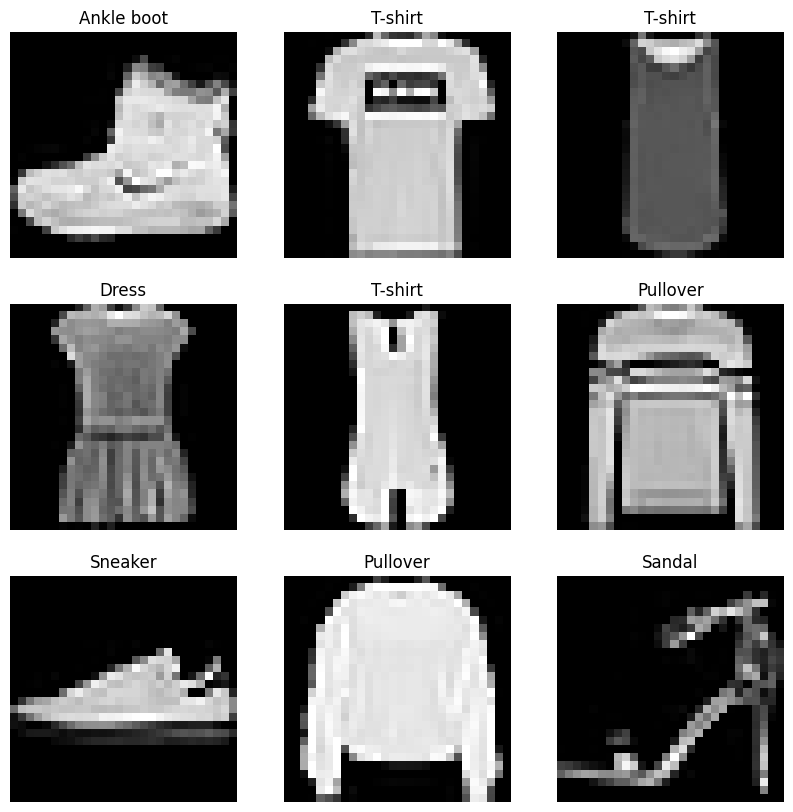

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8183 - loss: 0.5086 - val_accuracy: 0.8576 - val_loss: 0.3928
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8650 - loss: 0.3706 - val_accuracy: 0.8658 - val_loss: 0.3629
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8778 - loss: 0.3276 - val_accuracy: 0.8718 - val_loss: 0.3561
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8864 - loss: 0.3058 - val_accuracy: 0.8627 - val_loss: 0.3710
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8913 - loss: 0.2864 - val_accuracy: 0.8729 - val_loss: 0.3553
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8975 - loss: 0.2725 - val_accuracy: 0.8770 - val_loss: 0.3338
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9025 - loss: 0.2585 - val_accuracy: 0.8884 - val_loss: 0.3123
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9062 - loss: 0.2477 - val_accuracy: 0

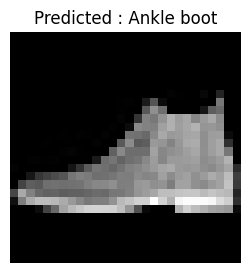

In [1]:
# Experiment No. 1
# Title: Keras Classification using Fashion MNIST Dataset

# Aim:
# To implement a simple Artificial Neural Network using Keras
# for Fashion MNIST image classification.

# Import Libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Input

# Load Fashion MNIST Dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Class Labels
class_names = [
    'T-shirt',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

# Display Sample Images
plt.figure(figsize=(10,10))

for i in range(9):

    plt.subplot(3,3,i+1)

    plt.imshow(
        X_train[i],
        cmap='gray'
    )

    plt.title(
        class_names[y_train[i]]
    )

    plt.axis('off')

plt.show()

# Normalize Dataset
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build ANN Model
model = Sequential([

    Input(shape=(28,28)),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dense(
        128,
        activation='relu'
    ),

    Dense(
        10,
        activation='softmax'
    )
])

# Model Summary
model.summary()

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

# Evaluate Model
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("\nTest Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

# Predict Sample
prediction = model.predict(X_test[:1])

predicted_label = np.argmax(prediction)

print("\nPredicted Label :", class_names[predicted_label])

# Display Prediction Image
plt.figure(figsize=(3,3))

plt.imshow(
    X_test[0],
    cmap='gray'
)

plt.title(
    "Predicted : " + class_names[predicted_label]
)

plt.axis('off')

plt.show()

# Conclusion
# Successfully implemented a Keras based Artificial Neural Network
# using Fashion MNIST dataset for image classification.